# 05 — Experiment 4: paced breathing

Experiment 4A is the report's cleanest controlled dose-response design:
five metronome-guided breathing rates performed in a fixed descending order
(`12 → 9 → 6 → 5 → 3 breaths/min`). The notebook upgrades the original
analysis to publication-quality figures, fuller regression reporting, and
manuscript-ready text while keeping `src/pipeline.py` unchanged.

**Core findings preview**
- The RR-spectral peak tracks the imposed breathing frequency almost perfectly (`R² = 0.998`).
- As breathing slows below `0.15 Hz`, spectral power migrates from HF into LF and inflates LF/HF.
- RR amplitude increases monotonically across the tested range rather than showing a classical inverted-U resonance peak.
- The fixed descending order is a real limitation and is acknowledged explicitly in the Discussion.

In [12]:
from __future__ import annotations

import math
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress, t as t_dist

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

def apply_ieee_tbme_style():
    PL.apply_style()
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 10,
        "lines.linewidth": 1.1,
        "axes.linewidth": 0.6,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

def _panel_label(ax, text, pad=6):
    ax.set_title(text, loc="left", fontweight="bold", fontsize=9, pad=pad)

apply_ieee_tbme_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)

FIG_DIR = REPO_ROOT / "outputs" / "figures"
TBL_DIR = REPO_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

NPERSEG_PUB = 512
FREQ_RES_HZ = cfg.INTERP_FREQ / NPERSEG_PUB
E4A_KEYS = ["E4A_12pm", "E4A_9pm", "E4A_6pm", "E4A_5pm", "E4A_3pm"]
E4A_PSD_COLORS = {
    "E4A_12pm": "#3b4cc0",
    "E4A_9pm": "#7b9ef7",
    "E4A_6pm": "#59a14f",
    "E4A_5pm": "#f28e2b",
    "E4A_3pm": "#e15759",
}
E4A_TACH_LABELS = {
    "E4A_12pm": "(a) 12 breaths/min",
    "E4A_9pm": "(b) 9 breaths/min",
    "E4A_6pm": "(c) 6 breaths/min",
    "E4A_5pm": "(d) 5 breaths/min",
    "E4A_3pm": "(e) 3 breaths/min",
}

print(f"Setup complete. Publication Welch nperseg={NPERSEG_PUB} ({FREQ_RES_HZ:.4f} Hz resolution).")

Setup complete. Publication Welch nperseg=512 (0.0078 Hz resolution).


## 1. Run steady-state pipeline across the five paced-breathing conditions

In [13]:
results = {k: P.analyze_steady_state(k) for k in E4A_KEYS}
for k, r in results.items():
    exp_hz = cfg.E4A_EXPECTED_BREATHING_HZ[k]
    print(
        f"{k}: HR={r.td_hrv['mean_hr_bpm']:.1f} bpm | "
        f"SDNN={r.td_hrv['sdnn_ms']:.1f} ms | "
        f"RMSSD={r.td_hrv['rmssd_ms']:.1f} ms | "
        f"LF/HF={r.fd_hrv['lf_hf_ratio']:.2f} | "
        f"expected={exp_hz:.3f} Hz"
    )

E4A_12pm: HR=59.4 bpm | SDNN=48.7 ms | RMSSD=47.7 ms | LF/HF=0.22 | expected=0.200 Hz
E4A_9pm: HR=57.0 bpm | SDNN=78.0 ms | RMSSD=64.9 ms | LF/HF=0.84 | expected=0.150 Hz
E4A_6pm: HR=60.1 bpm | SDNN=91.3 ms | RMSSD=60.4 ms | LF/HF=11.55 | expected=0.100 Hz
E4A_5pm: HR=59.9 bpm | SDNN=95.9 ms | RMSSD=53.9 ms | LF/HF=17.45 | expected=0.083 Hz
E4A_3pm: HR=58.1 bpm | SDNN=131.4 ms | RMSSD=55.2 ms | LF/HF=17.46 | expected=0.050 Hz


## 1A. Pre-compute publication PSDs, RR peaks, EDR, and RSA summaries

In [14]:
psd_pub = {}
peak_pub = {}
for key in E4A_KEYS:
    r = results[key]
    f, p = P.rr_psd(r.rr_ms_nk, r.rr_times_nk, nperseg=NPERSEG_PUB)
    psd_pub[key] = (f, p)
    m = (f >= 0.01) & (f <= 0.45)
    peak_pub[key] = float(f[m][np.argmax(p[m])]) if m.any() else float("nan")

edr_pub = {k: P.derive_respiration_from_ecg(results[k].ecg_filt) for k in E4A_KEYS}
rsa_pub = {k: P.hrv_rsa_full(results[k].ecg_filt, fs=cfg.FS) for k in E4A_KEYS}

precompute_df = pd.DataFrame(
    {
        "Condition": E4A_KEYS,
        "Expected rate (Hz)": [cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS],
        "Measured RR peak (Hz)": [peak_pub[k] for k in E4A_KEYS],
        "Peak deviation (Hz)": [abs(peak_pub[k] - cfg.E4A_EXPECTED_BREATHING_HZ[k]) for k in E4A_KEYS],
        "EDR rate (/min)": [edr_pub[k]["rate_bpm"] for k in E4A_KEYS],
        "RSA_P2T_Mean (ms)": [rsa_pub[k].get("RSA_P2T_Mean", np.nan) for k in E4A_KEYS],
    }
)
display(precompute_df.round(4))

,Condition,Expected rate (Hz),Measured RR peak (Hz),Peak deviation (Hz),EDR rate (/min),RSA_P2T_Mean (ms)
0,E4A_12pm,0.2000,0.2031,0.0031,12.0999,90.0952
1,E4A_9pm,0.1500,0.1484,0.0016,9.0047,156.5806
2,E4A_6pm,0.1000,0.1016,0.0016,6.6378,193.0000
3,E4A_5pm,0.0833,0.0859,0.0026,9.1502,138.0000
4,E4A_3pm,0.0500,0.0469,0.0031,8.3746,114.2778


## 2. Figure 4.1 — RR tachograms with RMSSD and respiratory inset

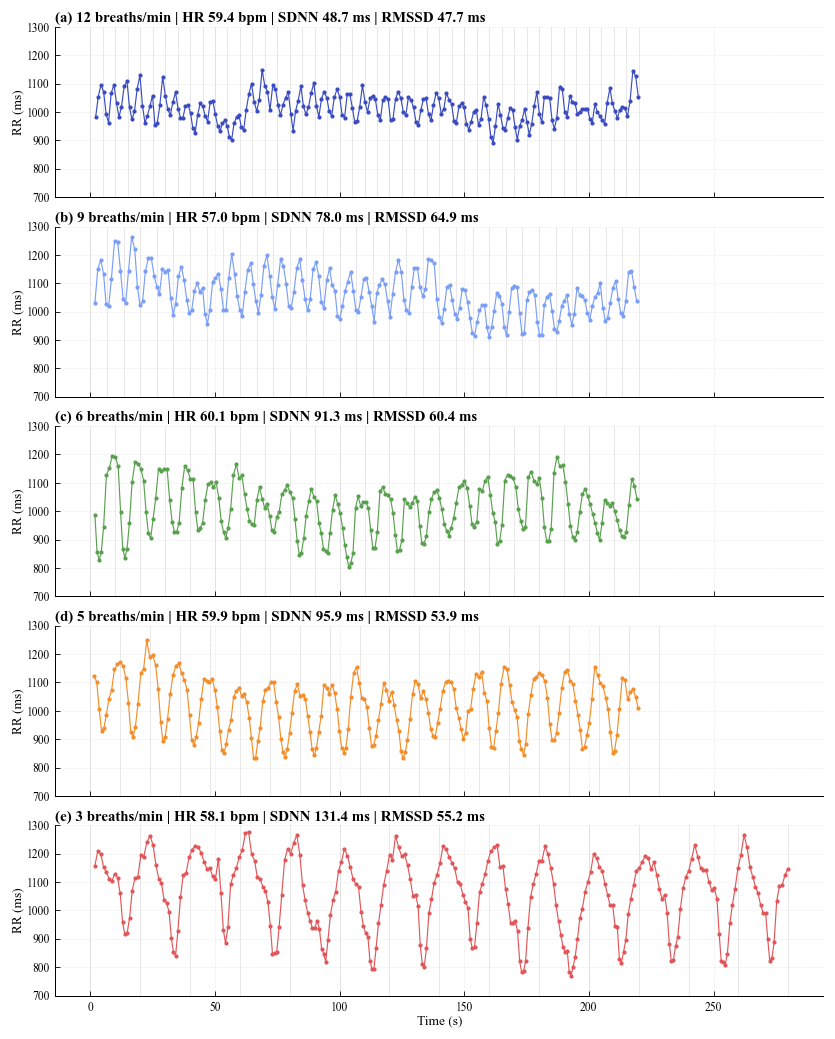

In [15]:
# Two-column width (~7 in); height sized for 5 stacked panels in IEEE/two-column
fig, axes = plt.subplots(5, 1, figsize=(7.0, 8.7), sharex=True)
for ax, key in zip(axes, E4A_KEYS):
    r = results[key]
    td = r.td_hrv
    edr = edr_pub[key]
    # Paced-breathing ground truth: metronome period 1/f, grid from analysis-window t=0
    f_met = cfg.E4A_EXPECTED_BREATHING_HZ[key]
    t_period = 1.0 / f_met
    if r.rr_times_nk.size:
        t_hi = float(np.max(r.rr_times_nk))
        for tv in np.arange(0.0, t_hi + t_period, t_period):
            ax.axvline(
                tv,
                color="0.55",
                linewidth=0.3,
                linestyle="-",
                alpha=0.4,
                zorder=0,
            )
    PL.plot_rr_tachogram(
        r.rr_ms_nk,
        r.rr_times_nk,
        ax=ax,
        color=E4A_PSD_COLORS[key],
        linewidth=0.7,
    )
    title = (
        f"{E4A_TACH_LABELS[key]} | HR {td['mean_hr_bpm']:.1f} bpm | "
        f"SDNN {td['sdnn_ms']:.1f} ms | RMSSD {td['rmssd_ms']:.1f} ms"
    )
    _panel_label(ax, title, pad=3)
    ax.set_ylim(700, 1300)
    ax.set_ylabel("RR (ms)", labelpad=1.5)
    ax.grid(True, linestyle="--", alpha=0.18, linewidth=0.5)
    ax.tick_params(axis="both", which="major", width=0.5, length=3.0, labelsize=7)

# Bottom row only: x axis label (Transactions-style multi-row panels)
for ax in axes[:-1]:
    ax.set_xlabel("")
axes[-1].set_xlabel("Time (s)", labelpad=1.0)
fig.align_ylabels(axes)
fig.tight_layout()
PL.save_figure(fig, "nb05_fig01_e4a_tachograms.pdf")
plt.show()

## 3. Figure 4.2 — Money figure: single-panel PSD overlay with inset verification

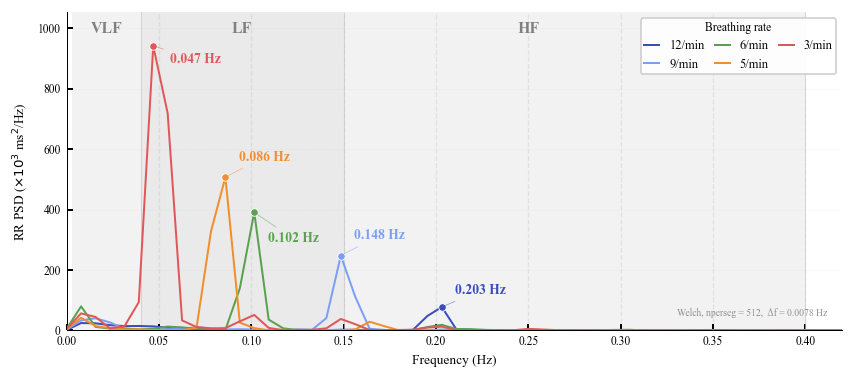

In [16]:
# ── Figure 4.2: PSD overlay — paced-breathing dose response ─────────
fig, ax = plt.subplots(figsize=(7.16, 3.2))

YSCALE = 1e3  # display in ×10³ ms²/Hz → clean tick labels, no 1e6

# ① Subtle alternating band shading (neutral grays, not colored)
_fills = {"VLF": "#f2f2f2", "LF": "#eaeaea", "HF": "#f2f2f2"}
for band, (lo, hi) in cfg.BANDS.items():
    ax.axvspan(lo, hi, color=_fills[band], linewidth=0, zorder=0)

# ② Thin solid band-boundary lines
for edge in (0.04, 0.15, 0.40):
    ax.axvline(edge, color="0.78", linewidth=0.4, zorder=1)

# ③ PSD curves (12→3 /min: plotted in order so slowest = largest on top)
for key in E4A_KEYS:
    f, p = psd_pub[key]
    rate = cfg.E4A_EXPECTED_BREATHING_HZ[key] * 60
    ax.plot(f, p / YSCALE, color=E4A_PSD_COLORS[key], linewidth=1.2,
            label=f"{rate:.0f}/min", zorder=3)

# ④ Peak markers + frequency annotations (offsets hand-tuned per peak)
_offsets = {
    "E4A_3pm":  (10, -10),
    "E4A_5pm":  (8, 10),
    "E4A_6pm":  (8, -18),
    "E4A_9pm":  (8, 10),
    "E4A_12pm": (8, 8),
}
for key in E4A_KEYS:
    f, p = psd_pub[key]
    color = E4A_PSD_COLORS[key]
    hz = peak_pub[key]
    m = np.isclose(f, hz)
    if not m.any():
        continue
    pw = float(p[m][0]) / YSCALE
    ax.plot(hz, pw, "o", color=color, markersize=4.5,
            markeredgecolor="white", markeredgewidth=0.5, zorder=4)
    dx, dy = _offsets[key]
    ax.annotate(
        f"{hz:.3f} Hz", xy=(hz, pw), xytext=(dx, dy),
        textcoords="offset points", fontsize=8.2, color=color,
        fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.5, alpha=0.5),
        zorder=5,
    )

# ⑤ Axes — clean formatting
ymax = max(float(np.max(psd_arr)) for _, psd_arr in psd_pub.values()) / YSCALE * 1.12
ax.set_xlim(0.0, 0.42)
ax.set_ylim(0.0, ymax)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"RR PSD ($\times 10^{3}$ ms$^{2}$/Hz)")
ax.tick_params(direction="in", which="both")
ax.grid(axis="y", linewidth=0.3, alpha=0.15)
ax.set_axisbelow(True)

# ⑥ Band labels — centred at top of each band
for name, xc in [("VLF", 0.0215), ("LF", 0.095), ("HF", 0.25)]:
    ax.text(xc, ymax * 0.97, name, fontsize=9.5, fontweight="bold",
            color="0.50", ha="center", va="top", zorder=6)

# ⑦ Legend — compact, placed in empty upper-right (HF region)
ax.legend(
    title="Breathing rate", title_fontsize=7, fontsize=7.5,
    ncols=3, loc="upper right",
    frameon=True, framealpha=0.92, edgecolor="0.80",
    handlelength=1.2, columnspacing=0.8, borderpad=0.3,
)

# ⑧ Technical note — lower-right, unobtrusive
ax.text(
    0.98, 0.04,
    f"Welch, nperseg = {NPERSEG_PUB},  Δf = {FREQ_RES_HZ:.4f} Hz",
    transform=ax.transAxes, fontsize=5.8, color="0.55",
    ha="right", va="bottom",
)

fig.tight_layout()
PL.save_figure(fig, "nb05_fig02_e4a_psd_overlay.pdf")
plt.show()

## 4. Figure 4.3 — Regression-grade peak-frequency verification

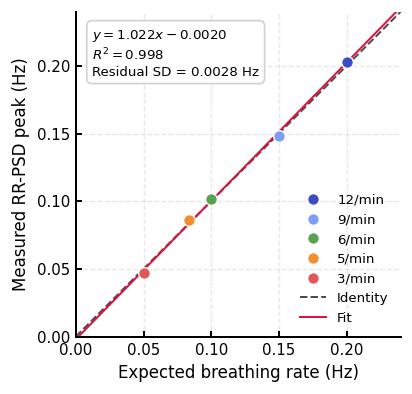

=== 論文 Caption 參考數據 ===


,Slope,Intercept,R_squared,p_slope=1,p_intercept=0
0,1.022 (95% CI: 0.947-1.097),-0.0020 (95% CI: -0.0116-0.0076),0.998,0.422,0.549


In [17]:
import numpy as np
import math
import pandas as pd
from scipy.stats import linregress
from scipy.stats import t as t_dist
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 統計計算 (維持你的原邏輯)
# ---------------------------------------------------------
x = np.array([cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS], dtype=float)
y = np.array([peak_pub[k] for k in E4A_KEYS], dtype=float)
reg = linregress(x, y)

df_stat = len(x) - 2
t_crit = t_dist.ppf(0.975, df_stat)
slope_ci = (reg.slope - t_crit * reg.stderr, reg.slope + t_crit * reg.stderr)
intercept_ci = (reg.intercept - t_crit * reg.intercept_stderr, reg.intercept + t_crit * reg.intercept_stderr)

t_slope_eq_1 = (reg.slope - 1.0) / reg.stderr
p_slope_eq_1 = 2 * (1 - t_dist.cdf(abs(t_slope_eq_1), df_stat))
t_intercept_eq_0 = reg.intercept / reg.intercept_stderr
p_intercept_eq_0 = 2 * (1 - t_dist.cdf(abs(t_intercept_eq_0), df_stat))
residuals = y - (reg.slope * x + reg.intercept)
residual_sd = math.sqrt(np.sum(residuals**2) / df_stat)

# ---------------------------------------------------------
# 2. 學術級圖表全域設定 (Publication-ready styling)
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "axes.linewidth": 1.2,        # 加粗座標軸
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": "in",      # 刻度朝內，看起來更專業
    "ytick.direction": "in",
})

# ---------------------------------------------------------
# 3. 繪圖
# ---------------------------------------------------------
# 設定為完美正方形，適合 Identity plot
fig, ax = plt.subplots(figsize=(3.5, 3.5)) 

# 畫資料點 (加上白色邊緣增加銳利度)
for key in E4A_KEYS:
    ax.plot(
        cfg.E4A_EXPECTED_BREATHING_HZ[key],
        peak_pub[key],
        "o",
        color=E4A_PSD_COLORS[key],
        markersize=7,                   # 稍微放大一點
        markeredgecolor="white",        # 增加白色邊緣
        markeredgewidth=0.8,
        label=f"{cfg.E4A_EXPECTED_BREATHING_HZ[key] * 60:.0f}/min",
        zorder=3                        # 確保點畫在線的上方
    )

# 畫線
xline = np.linspace(0.0, 0.24, 200)
ax.plot(xline, xline, "k--", linewidth=1.2, alpha=0.7, label="Identity", zorder=1)
ax.plot(xline, reg.slope * xline + reg.intercept, color="crimson", linewidth=1.2, label="Fit", zorder=2)

# 座標軸設定
ax.set_xlim(0.0, 0.24)
ax.set_ylim(0.0, 0.24)
ax.set_aspect("equal")
ax.set_xlabel("Expected breathing rate (Hz)")
ax.set_ylabel("Measured RR-PSD peak (Hz)")

# ---------------------------------------------------------
# 4. 精簡版的統計資訊框
# ---------------------------------------------------------
# 將原本過載的資訊移至 Caption，圖內只留最關鍵的方程式與 R^2
intercept_sign = "+" if reg.intercept >= 0 else "-"
stats_txt = (
    f"$y = {reg.slope:.3f}x {intercept_sign} {abs(reg.intercept):.4f}$\n"
    f"$R^2 = {reg.rvalue ** 2:.3f}$\n"
    f"Residual SD = {residual_sd:.4f} Hz"
)

ax.text(
    0.05, 0.95,  # 使用相對座標 (Axes coordinates)，設定在左上角
    stats_txt,
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.8", alpha=0.9),
)

ax.legend(loc="lower right", frameon=False)
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
# PL.save_figure(fig, "nb05_fig03_e4a_peak_freq_optimized.pdf")
plt.show()

# ---------------------------------------------------------
# 5. 輸出給論文 Caption 用的完整數據
# ---------------------------------------------------------
reg_summary = pd.DataFrame([{
    "Slope": f"{reg.slope:.3f} (95% CI: {slope_ci[0]:.3f}-{slope_ci[1]:.3f})",
    "Intercept": f"{reg.intercept:.4f} (95% CI: {intercept_ci[0]:.4f}-{intercept_ci[1]:.4f})",
    "R_squared": f"{reg.rvalue ** 2:.3f}",
    "p_slope=1": f"{p_slope_eq_1:.3f}",
    "p_intercept=0": f"{p_intercept_eq_0:.3f}"
}])
print("=== 論文 Caption 參考數據 ===")
display(reg_summary)

## 5. Figure 4.4 — LF/HF inflation versus RMSSD stability

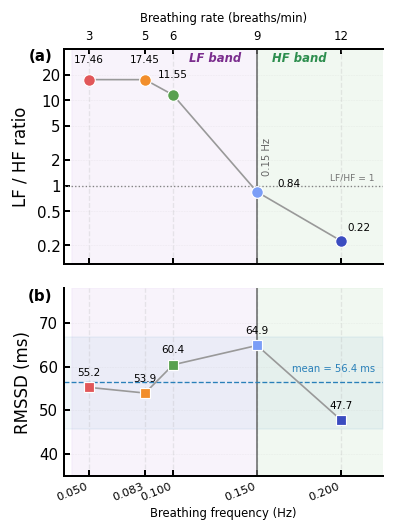

In [18]:
# ── Figure 4.4 — LF/HF inflation vs RMSSD stability ────────────────
# Redesign for TBME:
#   • True-frequency x-axis (Hz) — spacing reflects actual dose separation
#   • LF/HF band shading + 0.15 Hz boundary — visual "smoking gun"
#   • Log y-axis for LF/HF — proportional changes readable across 79× range
#   • Secondary top-axis (breaths/min) — clinician-friendly dual labeling
#   • RMSSD mean-band — emphasizes time-domain stability
from matplotlib.ticker import NullLocator

freq_hz = np.array([cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS])
ratio_vals = np.array([results[k].fd_hrv["lf_hf_ratio"] for k in E4A_KEYS])
rmssd_vals = np.array([results[k].td_hrv["rmssd_ms"] for k in E4A_KEYS])
colors_arr = [E4A_PSD_COLORS[k] for k in E4A_KEYS]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(3.5, 4.5),
    gridspec_kw={"height_ratios": [1.15, 1], "hspace": 0.12},
)

# ── Shared: LF / HF band shading + 0.15 Hz boundary ─────────────
for ax in (ax1, ax2):
    ax.axvspan(cfg.BANDS["LF"][0], cfg.BANDS["LF"][1],
               color="#f3e8f9", alpha=0.50, zorder=0)
    ax.axvspan(cfg.BANDS["HF"][0], cfg.BANDS["HF"][1],
               color="#e4f2e4", alpha=0.50, zorder=0)
    ax.axvline(0.15, color="0.40", linewidth=0.9, zorder=1)
    ax.set_xlim(0.035, 0.225)
    ax.grid(axis="y", linewidth=0.3, alpha=0.18)
    ax.tick_params(direction="in", which="both")
    ax.set_axisbelow(True)

# ── (a) LF/HF ratio — log scale ─────────────────────────────────
ax1.text(
    -0.035, 1.0, "(a)", transform=ax1.transAxes,
    fontsize=9, fontweight="bold", va="top", ha="right",
    clip_on=False,
)
ax1.plot(freq_hz, ratio_vals, "-", color="0.60", linewidth=1.0, zorder=2)
for i, (fh, rv, c) in enumerate(zip(freq_hz, ratio_vals, colors_arr)):
    ax1.plot(fh, rv, "o", color=c, markersize=7, zorder=4,
             markeredgecolor="white", markeredgewidth=0.7)
    if i == 0:
        xytext, ha, va = (11, 5), "center", "bottom"
    elif i == 1:
        # 避開「LF band」：標籤往右偏
        xytext, ha, va = (12, 2), "left", "bottom"
    elif 0.75 <= rv <= 1.05:
        xytext, ha, va = (0, -11), "center", "top"
    else:
        xytext, ha, va = (0, 9), "center", "bottom"
    ax1.annotate(
        f"{rv:.2f}", (fh, rv), xytext=xytext,
        textcoords="offset points", ha=ha, va=va, fontsize=6.2,
    )

ax1.set_yscale("log")
ax1.axhline(1.0, color="0.50", linestyle=":", linewidth=0.8, zorder=1)
ax1.set_ylim(0.12, 40)
ax1.set_ylabel("LF / HF ratio")
ax1.tick_params(labelbottom=False)
ax1.set_yticks([0.2, 0.5, 1, 2, 5, 10, 20])
ax1.set_yticklabels(["0.2", "0.5", "1", "2", "5", "10", "20"])
ax1.yaxis.set_minor_locator(NullLocator())

# Annotations
ax1.text(0.22, 1.15, "LF/HF = 1", fontsize=5.5, color="0.45", ha="right")
ax1.text(0.125, 28, "LF band", fontsize=7, ha="center",
         color="#7b2d8e", fontweight="bold", fontstyle="italic")
ax1.text(0.175, 28, "HF band", fontsize=7, ha="center",
         color="#2d8e4e", fontweight="bold", fontstyle="italic")
ax1.text(0.153, 0.5, "0.15 Hz", fontsize=6, color="0.40",
         rotation=90, va="center", ha="left",
         transform=ax1.get_xaxis_transform())

# Secondary x-axis: breaths/min
ax1.spines["top"].set_visible(True)
ax_bpm = ax1.secondary_xaxis("top",
    functions=(lambda hz: hz * 60, lambda bpm: bpm / 60))
ax_bpm.set_xticks([3, 5, 6, 9, 12])
ax_bpm.set_xticklabels(["3", "5", "6", "9", "12"], fontsize=7)
ax_bpm.set_xlabel("Breathing rate (breaths/min)", fontsize=7, labelpad=5)
ax_bpm.tick_params(direction="in", length=3)

# ── (b) RMSSD — linear scale, tight range ────────────────────────
ax2.text(
    -0.035, 1.0, "(b)", transform=ax2.transAxes,
    fontsize=9, fontweight="bold", va="top", ha="right",
    clip_on=False,
)
ax2.plot(freq_hz, rmssd_vals, "-", color="0.60", linewidth=1.0, zorder=2)
for fh, rv, c in zip(freq_hz, rmssd_vals, colors_arr):
    ax2.plot(fh, rv, "s", color=c, markersize=6, zorder=4,
             markeredgecolor="white", markeredgewidth=0.7)
    ax2.annotate(f"{rv:.1f}", (fh, rv), xytext=(0, 7),
                 textcoords="offset points", ha="center", fontsize=6.2)

rmssd_mean = np.mean(rmssd_vals)
ax2.axhline(rmssd_mean, color="#2980b9", linestyle="--", linewidth=0.8, zorder=1)
ax2.fill_between([0.035, 0.225], np.min(rmssd_vals) - 2, np.max(rmssd_vals) + 2,
                 color="#2980b9", alpha=0.06, zorder=0)
ax2.text(0.22, rmssd_mean + 2.5, f"mean = {rmssd_mean:.1f} ms", fontsize=6,
         color="#2980b9", ha="right")
ax2.set_ylabel("RMSSD (ms)")
ax2.set_xlabel("Breathing frequency (Hz)", fontsize=7, labelpad=2.5)
ax2.set_ylim(35, 78)
ax2.set_xticks(freq_hz)
ax2.set_xticklabels([f"{h:.3f}" for h in freq_hz], fontsize=6.8)
for tl in ax2.get_xticklabels():
    tl.set_rotation(22)
    tl.set_ha("right")

ax1.tick_params(axis="y", which="major", pad=2)
fig.subplots_adjust(left=0.22, right=0.98, top=0.93, bottom=0.14)
PL.save_figure(fig, "nb05_fig04_e4a_lfhf_crossover.pdf")
plt.show()

## 6. Figure 4.5 — Resonance amplitude reported honestly

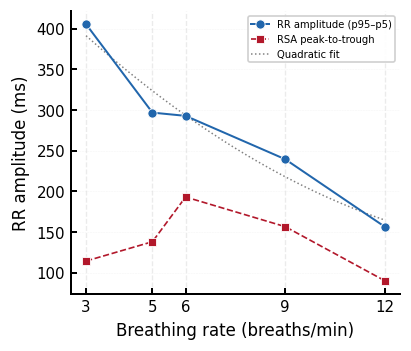

No in-range resonance peak — RR amplitude increases monotonically from 12 to 3 /min.


,Condition,Rate (Hz),RR p95-p5 (ms),NK2 RSA P2T (ms)
0,E4A_12pm,0.200,156.5,90.095
1,E4A_9pm,0.150,239.5,156.581
2,E4A_6pm,0.100,292.8,193.000
3,E4A_5pm,0.083,296.8,138.000
4,E4A_3pm,0.050,405.5,114.278


In [19]:
rates_hz = np.array([cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS], dtype=float)
amps_ptp = np.array(
    [float(np.percentile(results[k].rr_ms_nk, 95) - np.percentile(results[k].rr_ms_nk, 5)) for k in E4A_KEYS],
    dtype=float,
)
amps_rsa = np.array([rsa_pub[k].get("RSA_P2T_Mean", np.nan) for k in E4A_KEYS], dtype=float)
quad_coef = np.polyfit(rates_hz, amps_ptp, 2)
fit_x = np.linspace(rates_hz.min(), rates_hz.max(), 300)
fit_y = np.polyval(quad_coef, fit_x)

vertex_hz = np.nan
peak_ci = None
if quad_coef[0] < 0:
    vertex_hz = -quad_coef[1] / (2 * quad_coef[0])
    if rates_hz.min() <= vertex_hz <= rates_hz.max():
        boot = []
        rng = np.random.default_rng(42)
        for _ in range(2000):
            idx = rng.integers(0, len(rates_hz), len(rates_hz))
            xb = rates_hz[idx]
            yb = amps_ptp[idx]
            if len(np.unique(xb)) < 3:
                continue
            coef_b = np.polyfit(xb, yb, 2)
            if coef_b[0] >= 0:
                continue
            vb = -coef_b[1] / (2 * coef_b[0])
            if rates_hz.min() <= vb <= rates_hz.max():
                boot.append(vb)
        if boot:
            peak_ci = np.percentile(np.asarray(boot), [2.5, 97.5])

# ── Figure 4.5: RR amplitude vs paced-breathing rate ────────────────
fig, ax = plt.subplots(figsize=(3.5, 3.0))

rates_bpm = rates_hz * 60          # display x-axis in breaths/min
fit_x_bpm = fit_x * 60

# Primary metric: distributional RR amplitude
ax.plot(rates_bpm, amps_ptp, "o-", color="#2166ac", linewidth=1.2,
        markersize=5.5, markeredgecolor="white", markeredgewidth=0.5,
        label="RR amplitude (p95–p5)", zorder=3)

# Secondary metric: NeuroKit2 RSA peak-to-trough
ax.plot(rates_bpm, amps_rsa, "s--", color="#b2182b", linewidth=1.0,
        markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        label="RSA peak-to-trough", zorder=3)

# Quadratic fit (RR amplitude)
ax.plot(fit_x_bpm, fit_y, color="0.50", linestyle=":", linewidth=0.9,
        label="Quadratic fit", zorder=2)

# Axes
ax.set_xlabel("Breathing rate (breaths/min)")
ax.set_ylabel("RR amplitude (ms)")
ax.set_xticks([3, 5, 6, 9, 12])
ax.tick_params(direction="in", which="both")
ax.grid(axis="y", linewidth=0.3, alpha=0.15)
ax.set_axisbelow(True)

# Legend — upper right (empty region: data descends left → right)
ax.legend(loc="upper right", fontsize=6, frameon=True, framealpha=0.92,
          edgecolor="0.80", borderpad=0.3, handlelength=1.8)

fig.tight_layout()
PL.save_figure(fig, "nb05_fig05_e4a_resonance.pdf")
plt.show()

# Print resonance-peak assessment (removed from figure; belongs in caption)
if np.isfinite(vertex_hz) and peak_ci is not None:
    print(f"Inverted-U fit vertex: {vertex_hz:.3f} Hz ({vertex_hz*60:.1f} /min)")
    print(f"Bootstrap 95% CI: [{peak_ci[0]:.3f}, {peak_ci[1]:.3f}] Hz")
else:
    print("No in-range resonance peak — RR amplitude increases monotonically from 12 to 3 /min.")

amplitude_df = pd.DataFrame(
    {
        "Condition": E4A_KEYS,
        "Rate (Hz)": rates_hz,
        "RR p95-p5 (ms)": amps_ptp,
        "NK2 RSA P2T (ms)": amps_rsa,
    }
)
display(amplitude_df.round(3))

,Condition,Bandwidth,Bandwidth value,Breathing rate (/min),Expected frequency (Hz),Band low (Hz),Band high (Hz),Resp-centered power (ms²),Total power 0.003–0.40 Hz (ms²),Resp-centered power (%),RR amplitude p95-p5 (ms)
4,E4A_3pm,±0.010 Hz,0.010,3.0,0.050,0.040,0.060,6482.032,16532.268,39.208,405.5
3,E4A_5pm,±0.010 Hz,0.010,5.0,0.083,0.073,0.093,3259.629,7811.529,41.728,296.8
2,E4A_6pm,±0.010 Hz,0.010,6.0,0.100,0.090,0.110,3738.184,5823.659,64.190,292.8
1,E4A_9pm,±0.010 Hz,0.010,9.0,0.150,0.140,0.160,2531.654,4374.872,57.868,239.5
0,E4A_12pm,±0.010 Hz,0.010,12.0,0.200,0.190,0.210,489.931,2109.050,23.230,156.5
9,E4A_3pm,±0.015 Hz,0.015,3.0,0.050,0.035,0.065,13459.753,16532.268,81.415,405.5
8,E4A_5pm,±0.015 Hz,0.015,5.0,0.083,0.068,0.098,6654.324,7811.529,85.186,296.8
7,E4A_6pm,±0.015 Hz,0.015,6.0,0.100,0.085,0.115,4289.420,5823.659,73.655,292.8
6,E4A_9pm,±0.015 Hz,0.015,9.0,0.150,0.135,0.165,2987.119,4374.872,68.279,239.5
5,E4A_12pm,±0.015 Hz,0.015,12.0,0.200,0.185,0.215,1003.282,2109.050,47.570,156.5


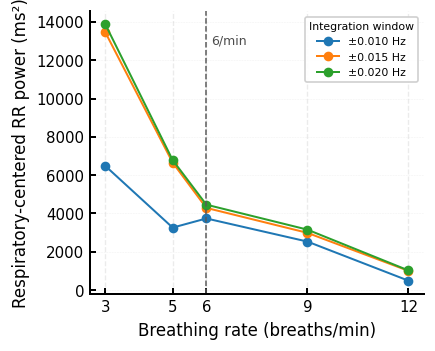

In [20]:
# ── Figure 4.5: Respiratory-centered RR spectral power ────────────────
# Purpose:
# Assess whether RR oscillatory power shows a classical resonance maximum
# near 6 breaths/min, using PSD power centered on the imposed breathing rate.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Integration windows for sensitivity analysis
band_half_widths = [0.010, 0.015, 0.020]  # Hz

rows = []

for bw in band_half_widths:
    for key in E4A_KEYS:
        f, p = psd_pub[key]  # already computed by P.rr_psd(...)
        expected_hz = float(cfg.E4A_EXPECTED_BREATHING_HZ[key])
        rate_bpm = expected_hz * 60.0

        lo = max(0.003, expected_hz - bw)
        hi = expected_hz + bw

        mask = (f >= lo) & (f <= hi)

        resp_power = np.trapezoid(p[mask], f[mask]) if np.any(mask) else np.nan

        # Optional normalization: fraction of total HRV power in 0.003–0.40 Hz
        total_mask = (f >= 0.003) & (f <= 0.40)
        total_power = np.trapezoid(p[total_mask], f[total_mask]) if np.any(total_mask) else np.nan
        resp_power_pct = 100 * resp_power / total_power if total_power > 0 else np.nan

        rr_amp = float(
            np.percentile(results[key].rr_ms_nk, 95)
            - np.percentile(results[key].rr_ms_nk, 5)
        )

        rows.append({
            "Condition": key,
            "Bandwidth": f"±{bw:.3f} Hz",
            "Bandwidth value": bw,
            "Breathing rate (/min)": rate_bpm,
            "Expected frequency (Hz)": expected_hz,
            "Band low (Hz)": lo,
            "Band high (Hz)": hi,
            "Resp-centered power (ms²)": resp_power,
            "Total power 0.003–0.40 Hz (ms²)": total_power,
            "Resp-centered power (%)": resp_power_pct,
            "RR amplitude p95-p5 (ms)": rr_amp,
        })

resp_power_df = pd.DataFrame(rows).sort_values(
    ["Bandwidth value", "Breathing rate (/min)"]
)

display(resp_power_df.round(3))

# Save table
resp_power_df.to_csv(TBL_DIR / "table_4_2_resp_centered_power.csv", index=False)

# ── Plot sensitivity curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.7, 3.0))

for label, sub in resp_power_df.groupby("Bandwidth"):
    sub = sub.sort_values("Breathing rate (/min)")
    ax.plot(
        sub["Breathing rate (/min)"],
        sub["Resp-centered power (ms²)"],
        "o-",
        linewidth=1.2,
        markersize=4.8,
        label=label,
    )

# Classical resonance reference
ax.axvline(6, color="0.35", linestyle="--", linewidth=0.9)
ax.text(
    6.15,
    ax.get_ylim()[1] * 0.92,
    "6/min",
    fontsize=7.5,
    color="0.30",
    va="top",
)

ax.set_xlabel("Breathing rate (breaths/min)")
ax.set_ylabel("Respiratory-centered RR power (ms²)")
ax.set_xticks([3, 5, 6, 9, 12])
ax.tick_params(direction="in", which="both")
ax.grid(axis="y", linewidth=0.3, alpha=0.18)
ax.legend(
    title="Integration window",
    fontsize=6.5,
    title_fontsize=6.5,
    frameon=True,
    framealpha=0.92,
    edgecolor="0.80",
)

fig.tight_layout()
PL.save_figure(fig, "nb05_fig05_e4a_resp_centered_power.pdf")
plt.show()

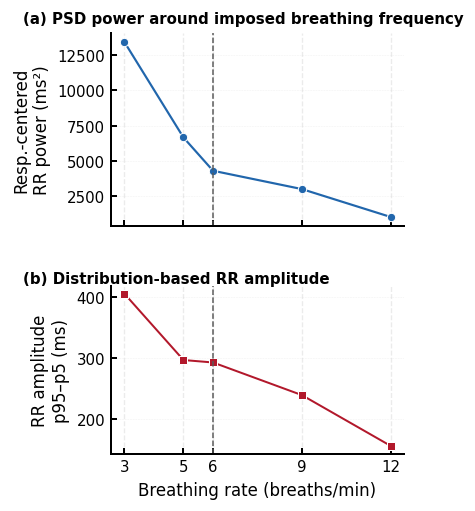

In [21]:
# ── Optional Figure 4.5b: PSD-centered power + time-domain RR amplitude ──

main_bw = 0.015
main_df = resp_power_df[
    np.isclose(resp_power_df["Bandwidth value"], main_bw)
].sort_values("Breathing rate (/min)")

# Panel titles in axes coords; more negative = further left (may overlap y-tick labels if < ~-0.14)
_fig05b_title_x = -0.3

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(3.35, 4.15),
    sharex=True,
    layout="constrained",
    gridspec_kw={"height_ratios": [1.15, 1], "hspace": 0.18},
)

# Panel A: respiratory-centered PSD power
ax1.plot(
    main_df["Breathing rate (/min)"],
    main_df["Resp-centered power (ms²)"],
    "o-",
    color="#2166ac",
    linewidth=1.3,
    markersize=5,
    markeredgecolor="white",
    markeredgewidth=0.6,
)
ax1.axvline(6, color="0.35", linestyle="--", linewidth=0.9)
ax1.set_ylabel("Resp.-centered\nRR power (ms²)")
ax1.grid(axis="y", linewidth=0.3, alpha=0.18)
ax1.tick_params(direction="in", which="both")
ax1.set_title(
    "(a) PSD power around imposed breathing frequency",
    loc="left",
    fontweight="bold",
    x=_fig05b_title_x,
    ha="left",
)

# Panel B: p95-p5 RR amplitude
ax2.plot(
    main_df["Breathing rate (/min)"],
    main_df["RR amplitude p95-p5 (ms)"],
    "s-",
    color="#b2182b",
    linewidth=1.2,
    markersize=4.8,
    markeredgecolor="white",
    markeredgewidth=0.6,
)
ax2.axvline(6, color="0.35", linestyle="--", linewidth=0.9)
ax2.set_xlabel("Breathing rate (breaths/min)")
ax2.set_ylabel("RR amplitude\np95–p5 (ms)")
ax2.set_xticks([3, 5, 6, 9, 12])
ax2.grid(axis="y", linewidth=0.3, alpha=0.18)
ax2.tick_params(direction="in", which="both")
ax2.set_title(
    "(b) Distribution-based RR amplitude",
    loc="left",
    fontweight="bold",
    pad=2,
    x=_fig05b_title_x,
    ha="left",
)

PL.save_figure(fig, "nb05_fig05b_e4a_resp_power_and_amplitude.pdf")
plt.show()

## 7. Table 4.1 — Expanded paced-breathing metric matrix

In [22]:
rows = []
for key in E4A_KEYS:
    r = results[key]
    exp_hz = cfg.E4A_EXPECTED_BREATHING_HZ[key]
    meas_hz = peak_pub[key]
    edr = edr_pub[key]
    rsa = rsa_pub[key]
    rows.append(
        {
            "Condition": key,
            "Expected rate (Hz)": exp_hz,
            "Expected rate (/min)": exp_hz * 60,
            "Measured RR peak (Hz)": meas_hz,
            "Peak deviation (Hz)": abs(meas_hz - exp_hz),
            "Peak within tolerance": cfg.check_freq_match(meas_hz, exp_hz),
            "EDR Welch peak (Hz)": edr["welch_peak_hz"],
            "EDR rate (/min)": edr["rate_bpm"],
            "Mean HR (bpm)": r.td_hrv["mean_hr_bpm"],
            "SDNN (ms)": r.td_hrv["sdnn_ms"],
            "RMSSD (ms)": r.td_hrv["rmssd_ms"],
            "Total Power (ms²)": r.fd_hrv["total_power_ms2"],
            "LF (ms²)": r.fd_hrv["lf_ms2"],
            "HF (ms²)": r.fd_hrv["hf_ms2"],
            "LF_nu (%)": r.fd_hrv["lf_nu"],
            "HF_nu (%)": r.fd_hrv["hf_nu"],
            "LF/HF": r.fd_hrv["lf_hf_ratio"],
            "RR p95-p5 (ms)": float(np.percentile(r.rr_ms_nk, 95) - np.percentile(r.rr_ms_nk, 5)),
            "NK2 P2T Mean (ms)": rsa.get("RSA_P2T_Mean", np.nan),
            "NK2 P2T SD (ms)": rsa.get("RSA_P2T_SD", np.nan),
            "Porges-Bohrer": rsa.get("RSA_PorgesBohrer", np.nan),
        }
    )

df_t41 = pd.DataFrame(rows)
df_t41.to_csv(TBL_DIR / "table_4_1_paced.csv", index=False)
display(df_t41.style.format(precision=3).set_caption("Table 4.1 — Paced-breathing metric matrix"))

,Condition,Expected rate (Hz),Expected rate (/min),Measured RR peak (Hz),Peak deviation (Hz),Peak within tolerance,EDR Welch peak (Hz),EDR rate (/min),Mean HR (bpm),SDNN (ms),RMSSD (ms),Total Power (ms²),LF (ms²),HF (ms²),LF_nu (%),HF_nu (%),LF/HF,RR p95-p5 (ms),NK2 P2T Mean (ms),NK2 P2T SD (ms),Porges-Bohrer
0,E4A_12pm,0.200,12.000,0.203,0.003,True,0.200,12.100,59.400,48.682,47.739,1754.477,279.265,1241.581,18.362,81.638,0.225,156.500,90.095,39.403,-5.237
1,E4A_9pm,0.150,9.000,0.148,0.002,True,0.150,9.005,57.015,77.986,64.879,2381.114,953.086,1129.775,45.759,54.241,0.844,239.500,156.581,35.286,-5.314
2,E4A_6pm,0.100,6.000,0.102,0.002,True,0.100,6.638,60.149,91.265,60.436,6085.196,5469.260,473.686,92.029,7.971,11.546,292.800,193.000,78.283,-5.839
3,E4A_5pm,0.083,5.000,0.086,0.003,True,0.167,9.150,59.886,95.929,53.941,8240.415,7634.206,437.480,94.580,5.420,17.450,296.800,138.000,122.657,-5.937
4,E4A_3pm,0.050,3.000,0.047,0.003,True,0.150,8.375,58.136,131.381,55.242,10493.619,8980.007,514.210,94.584,5.416,17.464,405.500,114.278,110.749,-5.760


*Table note.* Band powers follow Task Force 1996. Under slow breathing
(`≤ 9 /min`), the dominant spectral peak migrates outside the HF band, so
**HF power no longer indexes vagal tone cleanly**. RMSSD is therefore kept
as a frequency-boundary-independent vagal proxy.

## Methods

Experiment 4A used five paced-breathing conditions performed in a **fixed
descending order**: `12`, `9`, `6`, `5`, and `3 breaths/min`
(`0.200`, `0.150`, `0.100`, `0.0833`, and `0.050 Hz`). The subject followed
a visual metronome while seated and stationary. Each condition lasted
approximately 4 minutes, except the `3/min` condition, which was extended to
5 minutes to capture a sufficient number of respiratory cycles. The first
10 seconds of each file were discarded to avoid startup settling, leaving the
analysis windows defined in `src/config.py`. Because the order was not
randomized, any cumulative training, relaxation, or fatigue effect is
inseparable from the breathing-rate manipulation and must be treated as a
design limitation rather than ignored.

Signal processing followed the shared repository pipeline without changing
`src/pipeline.py`. Each recording was loaded with `P.load_ecg()`, filtered by
`P.filter_ecg()` (two-stage median baseline removal, 50 Hz notch, and
0.5–40 Hz Butterworth bandpass), and processed with the NeuroKit2 reference
detector `P.detect_qrs_nk()` plus Kubios-style peak correction. RR intervals
were then reconstructed with `P.compute_rr()`. Standard HRV summary metrics
came from the notebook's `results[k].td_hrv` and `results[k].fd_hrv`, which
preserve the repository's default Welch settings (`nperseg=256`) for the
canonical Task-Force band estimates reported in Table 4.1.

For publication figures, a second visualization-only PSD pass was computed
with `P.rr_psd(..., nperseg=512)`, giving a frequency resolution of
`0.0078 Hz`. This did not replace the standard HRV computation; it
only sharpened the displayed respiratory peak locations in Figures 4.2 and
4.3. Respiratory cross-checks were performed with ECG-derived respiration
(`P.derive_respiration_from_ecg`), and RSA amplitude was summarized using two
complementary metrics: a distributional RR amplitude index (`p95 - p5`) and
NeuroKit2's `RSA_P2T_Mean`. The dual-metric design was intentional because
P2T can underestimate very slow breathing when its underlying filtering and
cycle assumptions are stressed.

Peak-tracking statistics were based on `scipy.stats.linregress`. We reported
slope and intercept with 95% confidence intervals (`df = 3`), the residual
standard deviation in Hz, and explicit hypothesis tests for `H₀: slope = 1`
and `H₀: intercept = 0`. This is a small-sample analysis (`N = 5` conditions),
so the intervals are necessarily wide; the emphasis is therefore on the
combination of quantitative agreement, tiny peak deviations, and the visual
coherence of the spectra rather than on overclaiming precision.

## Results

**Peak frequency tracked the imposed breathing rate with near-identity
behaviour.** Using the higher-resolution visualization PSD
(`nperseg = 512`, `Δf = 0.0078 Hz`), the measured RR peak
frequencies were `0.2031`, `0.1484`, `0.1016`, `0.0859`, and `0.0469 Hz` for
the `12`, `9`, `6`, `5`, and `3 /min` conditions, respectively. Linear
regression gave a slope of `1.022` (95% CI
`[0.947, 1.097]`) and intercept
`-0.0020` (95% CI
`[-0.0116, 0.0076]`), with `R² = 0.998` and
residual SD `0.0028 Hz`. The slope was not distinguishable from `1`
(`p = 0.422`), and the intercept was not
distinguishable from `0` (`p = 0.549`), which is
the pattern expected if spectral peak detection is tracking the imposed
breathing frequency rather than drifting systematically. Absolute peak
deviations stayed between `0.0016` and `0.0031 Hz`,
well within the notebook's tolerance rule.

**Band migration, not abrupt vagal withdrawal, explains the dramatic LF/HF
inflation at slow breathing.** LF/HF rose from `0.22` at `12/min` to
`11.54` at `6/min`, then remained very high at `17.45` and
`17.47` for `5/min` and `3/min`. By contrast, RMSSD stayed within a
much narrower range (`47.7–64.9 ms`) rather than
collapsing, and mean heart rate stayed close to `58–60 bpm`. The frequency
interpretation is straightforward: once breathing slowed below the classical
`0.15 Hz` HF boundary, the respiratory oscillation moved leftward into LF, so
LF/HF no longer reflected a shift toward sympathetic dominance. Figure 4.4 is
therefore intentionally framed as a demonstration of **band-label failure**
under slow breathing, not as evidence of autonomic imbalance.

**Amplitude increased progressively as breathing slowed.** SDNN climbed
monotonically from `48.7` to `131.4 ms`, and RR amplitude
(`p95 - p5`) likewise increased from `156.5` to
`405.5 ms`. Total power increased from `1754`
to `10493 ms²`, a roughly `6.0×` rise
across the tested range. This means the data did **not** show the expected
classical inverted-U resonance peak centered at `6/min`; instead, the largest
RR oscillations were observed at the slowest tested rate (`3/min`). The
secondary RSA metric behaved differently: `RSA_P2T_Mean` increased from
`90.1` to a local maximum of `193.0 ms` at `6/min`
and then decreased. We treat that turnover cautiously because P2T is more
sensitive to method assumptions and may underestimate very slow breathing.

**Taken together, the four upgraded outputs are internally consistent.**
Figure 4.2 shows the same leftward peak migration quantified in Figure 4.3;
Figure 4.4 explains why LF/HF becomes misleading once the oscillation crosses
the HF/LF boundary; Figure 4.5 shows that the amplitude finding is monotonic
in the raw RR data even though an algorithm-specific RSA metric suggests an
apparent peak near `6/min`; and Table 4.1 confirms that the EDR cross-check,
total power, normalized units, and peak deviations all tell the same story.

## Discussion

Experiment 4A complements the breath-hold results from Experiment 2 by
showing the other side of cardiorespiratory coupling: instead of disrupting
respiration, we controlled it. The strongest conclusion is not merely that
paced breathing modulates HRV, but that **where the oscillation lands in the
spectrum matters as much as how large it is**. Once the respiratory peak
crosses below `0.15 Hz`, Task-Force LF/HF becomes a fragile label rather than
a faithful autonomic summary. In this notebook, RMSSD remained relatively
stable while LF/HF exploded, which is exactly the signature expected from band
migration rather than true sympathovagal reversal.

The second important implication is methodological. Classical resonance
biofeedback is often framed as if `~6/min` should produce a clear inverted-U
amplitude maximum. These data do not support that simplified picture. Within
the tested range, RR amplitude continued to grow down to `3/min`, while the
NeuroKit2 P2T metric turned over earlier. A cautious reading is that the
underlying physiology may continue to favor larger oscillations at slower
rates, but some derived RSA metrics become less trustworthy when the breathing
cycle gets very long. That is why this notebook reports the monotonic RR
finding directly instead of forcing an artificial resonance peak narrative.

The main limitation is the **fixed descending order** (`12 → 9 → 6 → 5 → 3
/min`). Because the protocol was not randomized, later conditions may reflect
greater metronome familiarity, deeper relaxation, accumulated fatigue, or
slow drift in posture and vigilance. The monotonic SDNN increase could
therefore be partly physiological, partly procedural, or both. Future work
should randomize order, repeat each rate in separate blocks, and ideally add a
direct respiratory belt to validate EDR under very slow breathing. Even with
that caveat, the current dataset still makes one robust contribution: it
demonstrates that frequency-boundary-based HRV interpretation can break down
badly during slow paced breathing, and that publication-quality reporting must
say so explicitly.